<h1 style="color:blue;text-align:center;">Unveiling the Android App Market</h1>
  

<h3 style="color:orange;">Step 1:Load the Datasets</h3>

Load the playstore apps dataset and user reviews dataset separately.

In [3]:
import pandas as pd
apps=pd.read_csv("googleplaystore/googleplaystore.csv")
reviews=pd.read_csv("googleplaystore_user_reviews/googleplaystore_user_reviews.csv")
print(apps.shape)
print(reviews.shape)

(10841, 13)
(64295, 5)


<h3 style="color:orange;">Step 2:Data Cleaning</h3>
We clean the apps dataset by:
<ul>
    <li>Fixing incorrect data types</li>
    <li>Handling missing values</li>
    <li>Removing duplicate rows</li>
</ul>


In [5]:
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [7]:
apps=apps.drop_duplicates(subset="App")                                                 # remove duplicate apps
apps["Installs"]=apps["Installs"].astype(str).str.replace(",","").str.replace("+","")  #clean installs column
apps["Installs"]=pd.to_numeric(apps["Installs"],errors="coerce")
apps["Price"]=apps["Price"].astype(str).str.replace("Free","0").str.replace("$","")   #clean price column
apps["Price"]=pd.to_numeric(apps["Price"],errors="coerce")
apps["Rating"]=apps["Rating"].fillna(apps["Rating"].mean())                             #fill missing rating values with the average rating
apps=apps.dropna(subset=["App","Category","Installs","Price"])
print(apps.shape)

(9659, 13)


<h3 style="color:orange;">Step 3:Category Analysis</h3>
This shows how apps are distributed across different categories.It helps identify the most common and highly saturated app categories.

Category
FAMILY      1832
GAME         959
TOOLS        827
BUSINESS     420
MEDICAL      395
Name: count, dtype: int64


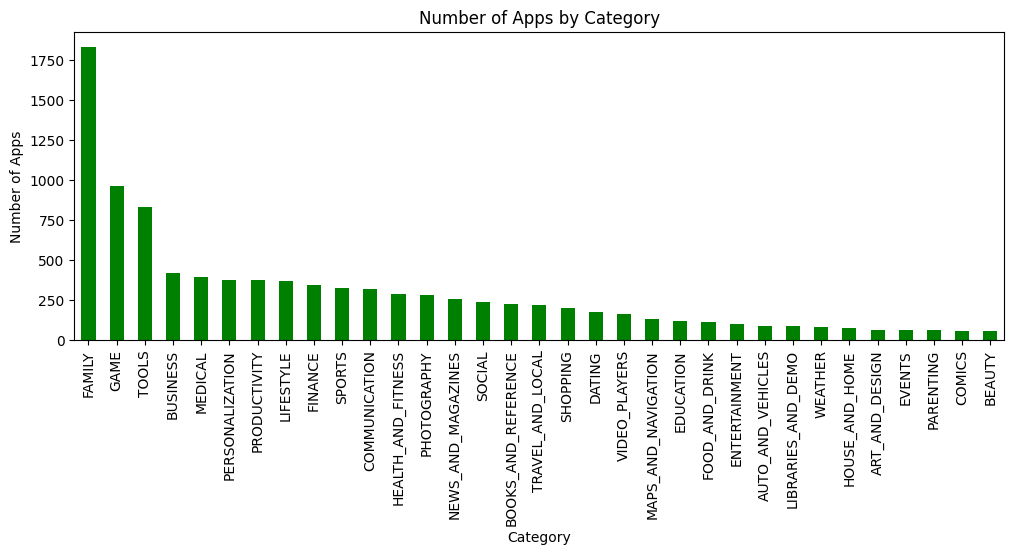

In [8]:
import matplotlib.pyplot as plt
category_counts=apps["Category"].value_counts()
print(category_counts.head())
category_counts.plot(kind="bar",figsize=(12,4),color="green")
plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)
plt.show()

<h3 style="color:orange;">Step 4:Rating Analysis</h3>

This helps us understand the overall quality of apps.We will examine the rating distribution and average rating for each category.



Category
EDUCATION              4.362816
EVENTS                 4.358219
ART_AND_DESIGN         4.348831
BOOKS_AND_REFERENCE    4.304404
PERSONALIZATION        4.299612
PARENTING              4.279175
BEAUTY                 4.257086
GAME                   4.243824
WEATHER                4.237030
SOCIAL                 4.236409
HEALTH_AND_FITNESS     4.232647
SHOPPING               4.224016
SPORTS                 4.207933
AUTO_AND_VEHICLES      4.188243
PRODUCTIVITY           4.181761
COMICS                 4.181252
FAMILY                 4.179100
LIBRARIES_AND_DEMO     4.177393
FOOD_AND_DRINK         4.172776
MEDICAL                4.168811
PHOTOGRAPHY            4.158544
HOUSE_AND_HOME         4.154062
ENTERTAINMENT          4.135294
NEWS_AND_MAGAZINES     4.132097
COMMUNICATION          4.131518
BUSINESS               4.127103
FINANCE                4.122977
LIFESTYLE              4.108411
TRAVEL_AND_LOCAL       4.084939
TOOLS                  4.057413
VIDEO_PLAYERS          4.056600

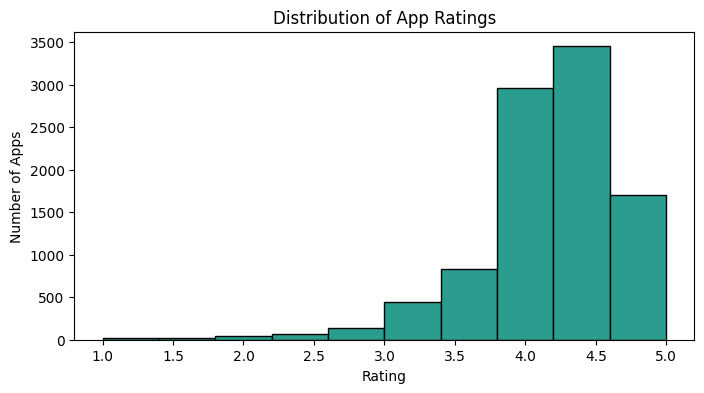

In [9]:
import matplotlib.pyplot as plt
apps["Rating"].plot(kind="hist",bins=10,figsize=(8,4),color="#2a9d8f",edgecolor="black")
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
avg_rating=apps.groupby("Category")["Rating"].mean().sort_values(ascending=False)
print(avg_rating)

<h3 style="color:orange;">Step 5:Size and Installs Analysis</h3>

This analysis studies the relationship between app size and the number of installs. A scatter plot is used to chexk whether larger apps tend to have more or fewer installs.


In [10]:
#convert size to MB
apps["Size"]=apps["Size"].astype(str)
apps["Size"]=apps["Size"].str.replace("M","", regex=False)
apps["Size"]=apps["Size"].str.replace("k","", regex=False)
apps["Size"]=pd.to_numeric(apps["Size"],errors="coerce")
print(apps["Size"].head())

0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64


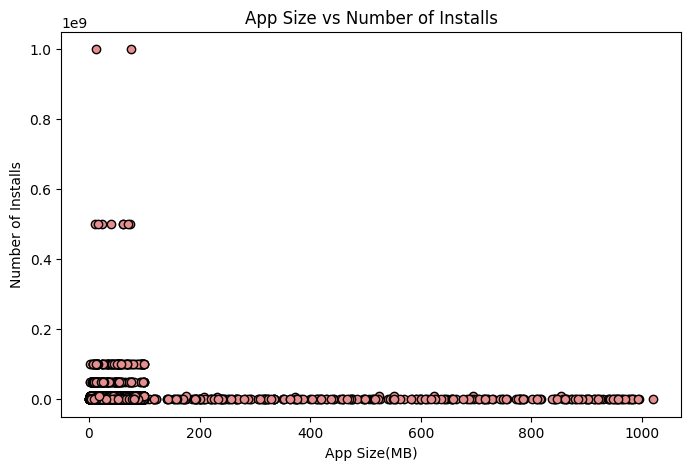

In [11]:
#Scatter plot:size vs installs
plt.figure(figsize=(8,5))
plt.scatter(apps["Size"],apps["Installs"],edgecolor="black",color="#e78f8f")
plt.title("App Size vs Number of Installs")
plt.xlabel("App Size(MB)")
plt.ylabel("Number of Installs")
plt.show()

In [12]:
correlation=apps["Size"].corr(apps["Installs"])
print("Correlation:",correlation)

Correlation: 0.006566053893504817


The correlation is approx 0.0007,so app size has almost no correlation with the number of installs.

<h3 style="color:orange;">Step 6:Pricing Analysis</h3>
Need to do 3 parts:
<ul>
    <li>Free vs Paid Apps</li>
    <li>Price distribution of paid apps</li>
    <li>Revenue estimate by category</li>
</ul>


Type
Free    8903
Paid     756
Name: count, dtype: int64


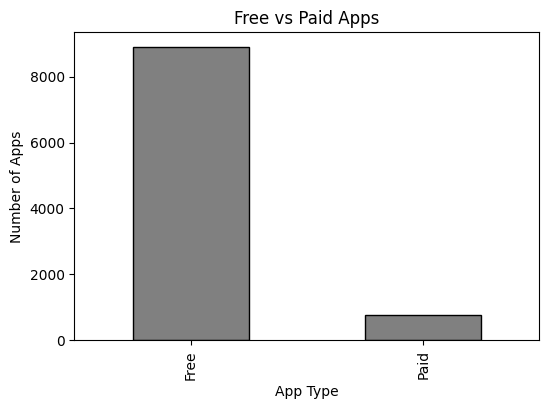

In [13]:
apps["Type"]=apps["Type"].fillna("Free")  #This shows how many apps are free and how many are paid.
type_counts=apps["Type"].value_counts()
print(type_counts),
type_counts.plot(kind="bar",figsize=(6,4),edgecolor="black",color="gray")
plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")
plt.show()

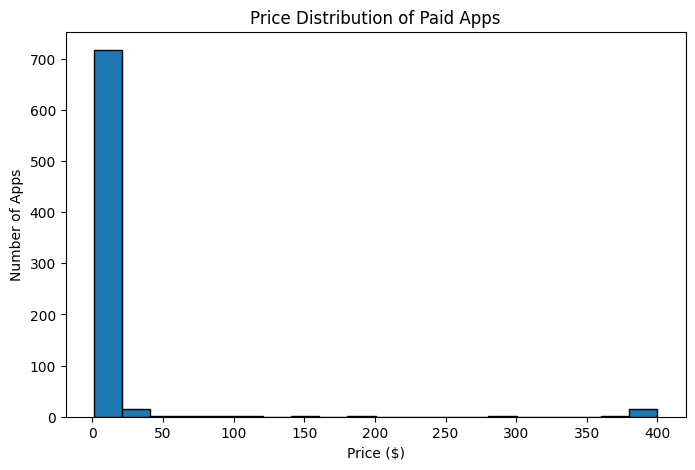

In [14]:
paid_apps=apps[apps["Price"]>0] #This shoows how the prices of paid apps are distributed
plt.figure(figsize=(8,5))
plt.hist(paid_apps["Price"],bins=20,edgecolor="black")
plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Number of Apps")
plt.show()

Most paid apps are available at lower prices,while only a few apps have higher prices.

Category
FAMILY             1.136798e+08
LIFESTYLE          5.758394e+07
GAME               4.068864e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.547768e+06
PERSONALIZATION    6.796948e+06
MEDICAL            5.957536e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Revenue, dtype: float64


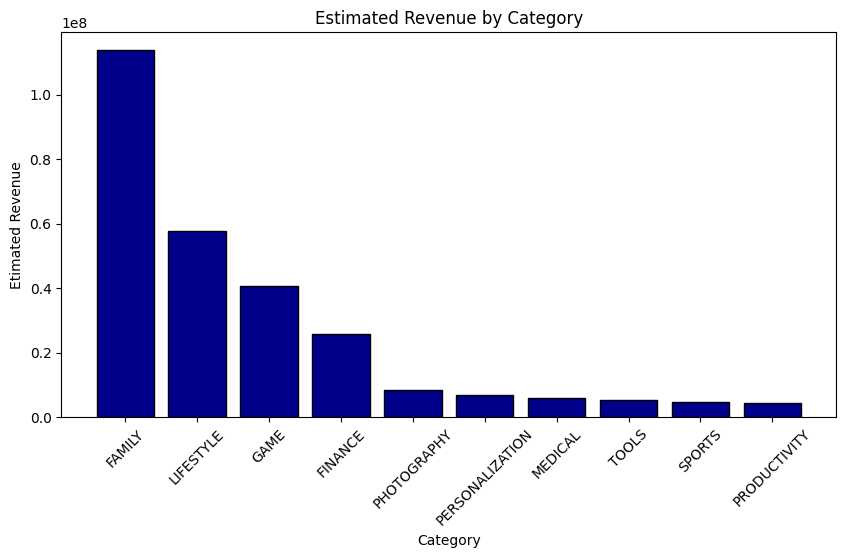

In [75]:
paid_apps=apps[apps["Price"]>0].copy()
paid_apps["Revenue"]=paid_apps["Price"]*paid_apps["Installs"]
revenue=paid_apps.groupby("Category")["Revenue"].sum()
top_revenue=revenue.sort_values(ascending=False).head(10)
print(top_revenue)
plt.figure(figsize=(10,5))
plt.bar(top_revenue.index,top_revenue.values,edgecolor="black",color="darkblue")
plt.title("Estimated Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Etimated Revenue")
plt.xticks(rotation=45)
plt.show()

Paid apps generate more revenue,so developers should focus on popular categories with high installs and positive user ratings.

<h3 style="color:orange;">Step 7:Sentiment Analysis</h3>

This classifies user reviews as positive,negative or neutral.Vader is used to analyse the sentiment of each review.

In [15]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sia=SentimentIntensityAnalyzer()
def get_sentiment(text):
    score=sia.polarity_scores(str(text))["compound"]
    if score>=0.05:
        return "Positive"
    elif score<=-0.05:
        return "Negative"
    else:
        return "Neutral"
reviews["Sentiment"]=reviews["Translated_Review"].apply(get_sentiment)
print(reviews[["Translated_Review",    "Sentiment"]].head())

                                   Translated_Review Sentiment
0  I like eat delicious food. That's I'm cooking ...  Positive
1    This help eating healthy exercise regular basis  Positive
2                                                NaN   Neutral
3         Works great especially going grocery store  Positive
4                                       Best idea us  Positive


<h3 style="color:orange;">Step 8:Sentiment by Category</h3>
Need to do 3 parts:
<ul>
    <li>Count Sentiments</li>
    <li>Add Category</li>
    <li>Compare Sentiments by Category</li>
</ul>


In [16]:
sentiment_counts=reviews.groupby(["App","Sentiment"]).size().unstack(fill_value=0) #This analysis compares user sentiment across app categories.
print(sentiment_counts.head())

Sentiment                         Negative  Neutral  Positive
App                                                          
10 Best Foods for You                   14       22       164
104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室         0        5        35
11st                                    13        8        19
1800 Contacts - Lens Store               6        6        68
1LINE – One Line with One Touch          5        8        27


In [17]:
reviews=reviews.merge(apps[["App","Category"]],#add category to reviews
                     on="App",
                      how="left")
print(reviews[["App","Category","Sentiment"]].head())

                     App            Category Sentiment
0  10 Best Foods for You  HEALTH_AND_FITNESS  Positive
1  10 Best Foods for You  HEALTH_AND_FITNESS  Positive
2  10 Best Foods for You  HEALTH_AND_FITNESS   Neutral
3  10 Best Foods for You  HEALTH_AND_FITNESS  Positive
4  10 Best Foods for You  HEALTH_AND_FITNESS  Positive


Sentiment           Negative  Neutral  Positive
Category                                       
GAME                    1437     4205      4898
HEALTH_AND_FITNESS       310     1377      1769
FAMILY                   343     2166      1460
TRAVEL_AND_LOCAL         384     1037      1079
DATING                   402     1620      1076
PRODUCTIVITY             296     1452      1012
SPORTS                   331     1281       988
MEDICAL                  233     1026       975
FINANCE                  347      901       952
TOOLS                    284     1394       934


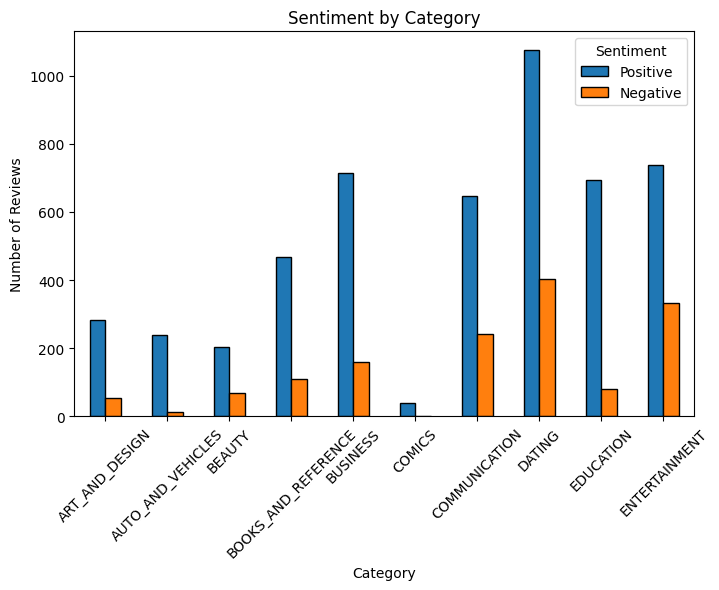

In [18]:
category_sentiment=reviews.groupby(["Category","Sentiment"]).size().unstack(fill_value=0) # count sentiment by category
print(category_sentiment.sort_values("Positive",ascending=False).head(10))
category_sentiment[["Positive","Negative"]].head(10).plot(
    kind="bar",
    figsize=(8,5),edgecolor="black"
)
plt.title("Sentiment by Category")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

<h3 style="color:orange">Step 9:Interactive Visualization</h3>
Plotly is used to create interactive charts.It allows users to hover the chart and view data values.

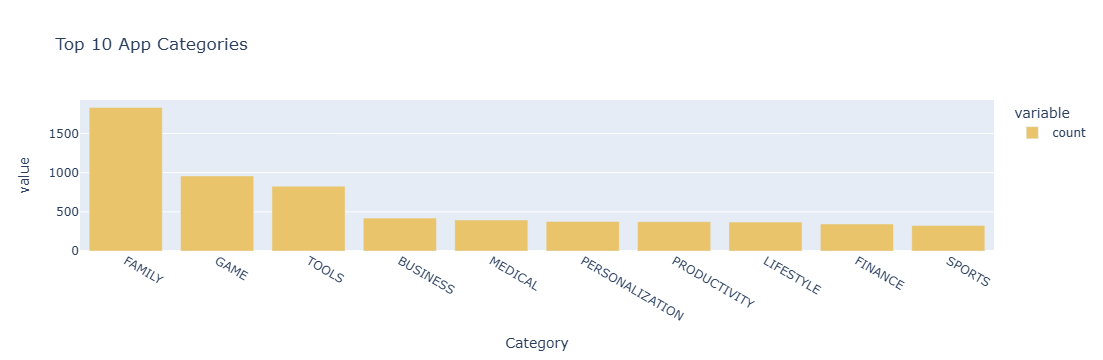

In [123]:
import plotly.express as px
fig=px.bar(category_counts.head(10),
           title="Top 10 App Categories",
        color_discrete_sequence=["#e9c46a"]  
          )
fig.show()

<h2 style="color:orange;">Conclusion:</h2>
This project analyzed Google Playstore apps and user reviews by performing data cleaning,category,ratings,size,installs and pricing analysis.Sentiment analysis was also performed using analysis VADER to classify reviews as positive,negative or neutral and visualizations were created to understand the results.These insights can help developers choose the right category,pricing strategy and improve user satisfaction when launching a new app.
                                        